In [ ]:
import os
from obspy import read
import pandas as pd

In [ ]:
DATA_FOLDER = r"C:\Users\raulm\Downloads\ai-devvnew\out\waveform.win\2026\03\09"

In [3]:
mseed_files = []

for root, dirs, files in os.walk(DATA_FOLDER):
    for f in files:
        if f.endswith(".mseed"):
            mseed_files.append(os.path.join(root, f))

len(mseed_files)

269

In [4]:
results = []

for file in sorted(mseed_files):

    try:
        st = read(file)
        st.merge(method=1)

        gaps = st.get_gaps()

        gap_count = len(gaps)
        overlap_count = sum(1 for g in gaps if g[6] < 0)

        tr = st[0]

        results.append({
            "file": file,
            "starttime": str(tr.stats.starttime),
            "endtime": str(tr.stats.endtime),
            "gap_count": gap_count,
            "overlap_count": overlap_count
        })

    except Exception as e:
        print("error reading:", file, e)

In [5]:
df = pd.DataFrame(results)

df

,file,starttime,endtime,gap_count,overlap_count
0,C:\Users\raulm\Downloads\ai-devvnew\out\wavefo...,2026-03-09T03:15:58.844538Z,2026-03-09T03:17:07.569538Z,0,0
1,C:\Users\raulm\Downloads\ai-devvnew\out\wavefo...,2026-03-09T03:17:07.594538Z,2026-03-09T03:18:17.169538Z,0,0
2,C:\Users\raulm\Downloads\ai-devvnew\out\wavefo...,2026-03-09T03:18:17.194538Z,2026-03-09T03:19:28.069538Z,0,0
3,C:\Users\raulm\Downloads\ai-devvnew\out\wavefo...,2026-03-09T03:19:28.094538Z,2026-03-09T03:20:38.569538Z,0,0
4,C:\Users\raulm\Downloads\ai-devvnew\out\wavefo...,2026-03-09T03:31:19.719539Z,2026-03-09T03:32:19.969539Z,0,0
...,...,...,...,...,...
264,C:\Users\raulm\Downloads\ai-devvnew\out\wavefo...,2026-03-09T04:18:45.194538Z,2026-03-09T04:19:46.969538Z,0,0
265,C:\Users\raulm\Downloads\ai-devvnew\out\wavefo...,2026-03-09T04:19:46.994538Z,2026-03-09T04:20:48.769538Z,0,0
266,C:\Users\raulm\Downloads\ai-devvnew\out\wavefo...,2026-03-09T04:20:48.794538Z,2026-03-09T04:21:50.569538Z,0,0
267,C:\Users\raulm\Downloads\ai-devvnew\out\wavefo...,2026-03-09T04:21:50.594538Z,2026-03-09T04:22:52.369538Z,0,0


In [6]:
print("Total files:", len(df))
print("Files with gaps:", (df.gap_count > 0).sum())
print("Files with overlap:", (df.overlap_count > 0).sum())

Total files: 269
Files with gaps: 0
Files with overlap: 0


In [7]:
df[df.gap_count > 0]

,file,starttime,endtime,gap_count,overlap_count


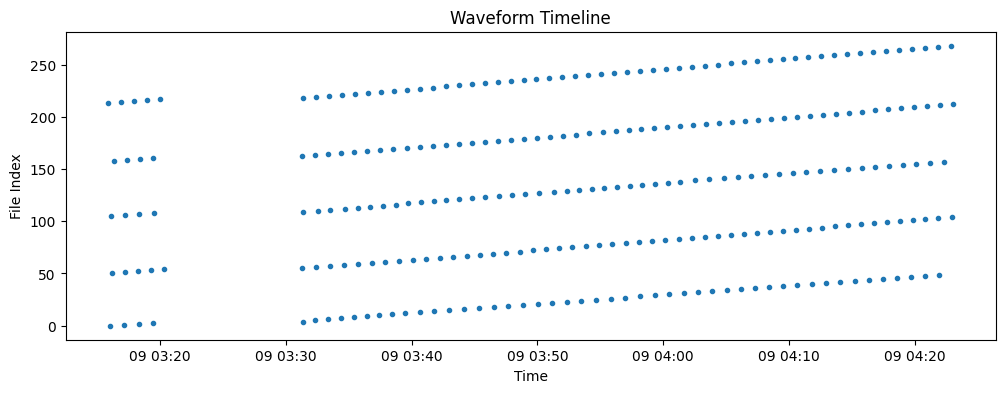

In [8]:
import matplotlib.pyplot as plt

times = pd.to_datetime(df["starttime"])

plt.figure(figsize=(12,4))
plt.plot(times, range(len(times)), ".")
plt.title("Waveform Timeline")
plt.xlabel("Time")
plt.ylabel("File Index")
plt.show()

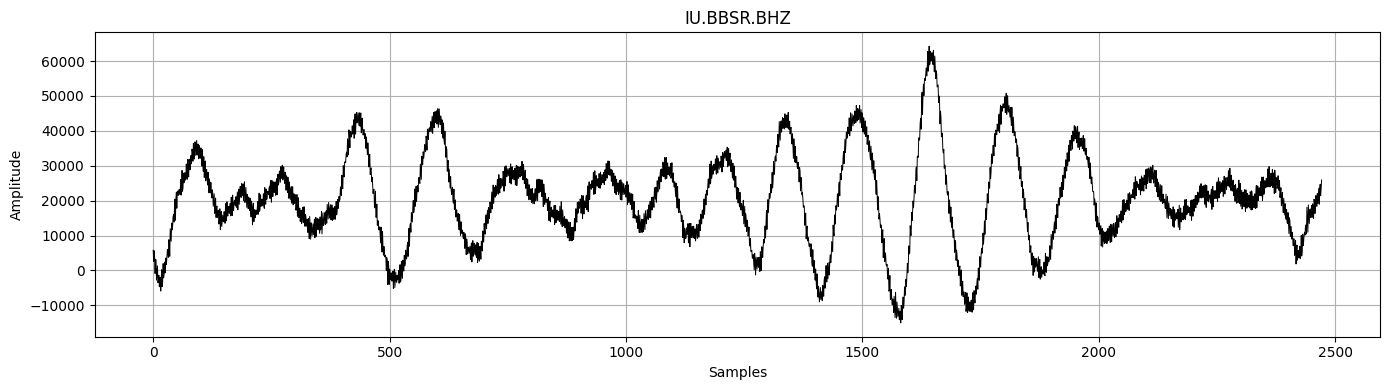

In [12]:
import matplotlib.pyplot as plt

tr = st[0]

plt.figure(figsize=(14,4))
plt.plot(tr.data, color="black", linewidth=0.7)

plt.title(f"{tr.stats.network}.{tr.stats.station}.{tr.stats.channel}")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.grid(True)
plt.tight_layout()
plt.show()